# Modelo Predictivo Precio Airbnb | Proyecto Final Ciencia de Datos 
---

## Objetive: 
To analyze Airbnb listings in order to predict listing prices and understand what factors have the biggest impact on said price. 

## Initial strategic decisions
1. *Raw price versus Log price*: The model will predict log prices instead of the raw prices on the listings in order to prioritize treating proportional differences in pricing the same across the board. This decision was made in order to gain a more symmetric, normal distribution so that the linear regression model works better. The tradeoff being the retransformation bias that occurs when converting from the log price back into dollar amounts.
2. *Models*: For this analysis there will only be one general model that predicts price listings regardless of room types. 
3. *Feature engineering*: In order to gain better insight into the factors affecting Airbnb prices there will be extensive feature engineering and the project will have a big focus on this area of the analysis. 

# 1. Exploratory Data Analysis
---
To begin the exploratory data analysis we will be answering the following questions:
- How many rows and columns does the dataset have?
- What does each column represent?

In [82]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import style
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns 
import csv
import datetime as dt
from utils import utilities

# import data 
excel = pd.read_excel('datosViviendas.xlsx', header = None)

# drop empty cells and convert lines to strings to read as a csv 
lines = excel[0].dropna().astype(str).tolist()
rows = list(csv.reader(lines))
header = rows[0]

# drop rows with incomplete or exceeding fields 
completeRows = [row for row in rows[1:] if len(row) == len(header)]

# initial EDA 
df = pd.DataFrame(completeRows, columns = header)
variables = list(df.columns)

print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")
print(f"The dataset contains the following variables: {variables}.\n")
print(f"The first rows of the dataset are:\n{df.head().to_string()}\n")


The dataset contains 63943 rows and 29 columns.

The dataset contains the following variables: ['id', 'log_price', 'property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'latitude', 'longitude', 'name', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'].

The first rows of the dataset are:
         id           log_price property_type        room_type                                                                                                                                                                                                                                                                                                                amenities accommodates bathrooms  bed_type cancellation_

# 1.1 Structural Overview
---
With my beginning analysis I made the following observations about the dataset:

| Variables              | What is it?                                                             | Data Type   |
| ---------------------- | ----------------------------------------------------------------------- | ----------- |
| id                     | Number that identifies the listing.                                     | str         |
| log_price              | Logarithmic price of the listing.                                       | float       |
| property_type          | Type of property (e.g. House/Apartment).                                | categorical |
| room_type              | Type of room (e.g. )                                                    | categorical |
| amenities              | List of amenities (e.g. TV, Wireless Internet, Air Conditioning, etc.)  | FE          |
| accommodates           | Number of people the property accommodates                              | int         |
| bathrooms              | number of bathrooms                                                     | float       |
| bed_type               | Type of bed                                                             | categorical |
| cancellation_policy    | How strict the cancellation policy is (e.g. strict/ moderate/flexible). | categorical |
| cleaning_fee           | Whether or not a cleaning fee exists.                                   | boolean     |
| city                   | The city the property is located in.                                    | categorical |
| description            | A description of the property.                                          | FE          |
| first_review           | Date of the first review.                                               | FE          |
| host_has_profile_pic   | Whether or not the listing host has a pfp.                              | boolean     |
| host_identity_verified | Whether or not the hosts identity is verified.                          | boolean     |
| host_response_rate     | Percent of times host responds to messages.                             | float       |
| host_since             | Date the Airbnb user became host.                                       | FE          |
| instant_bookable       | Whether or not the property is instantly bookable.                      | boolean     |
| last_review            | The last review's date.                                                 | FE          |
| latitude               | Latitude value.                                                         | FE          |
| longitude              | Longitude value.                                                        | FE          |
| name                   | Property/listing name.                                                  | FE          |
| neighbourhood          | What neighbourhood the property is in.                                  | categorical |
| number_of_reviews      | The number of reviews the listing has.                                  | int         |
| review_scores_rating   | The average rating of the review scores.                                | float       |
| thumbnail_url          | Url for posts thumbnail.                                                | FE          |
| zipcode                | Property's zip code.                                                    | FE          |
| bedrooms               | Number of bedrooms the property has.                                    | int         |
| beds                   | Number of beds the property has.                                        | int         |

In [83]:
# plan out what dtypes each column should be converted to for analysis and modeling
numeric_columns = ['accommodates', 'number_of_reviews', 'bedrooms', 'beds']
float_columns = ['log_price', 'bathrooms', 'review_scores_rating', 'host_response_rate']
categorical_columns = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'neighbourhood']
boolean_columns = ['cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable', ]
feature_engineering_columns = ['amenities', 'description', 'first_review', 'host_since', 'last_review', 'latitude', 'longitude', 'name', 'thumbnail_url', 'zipcode']

# visualize unique values to determine if any erroneous values exist 
for col in numeric_columns:
    print(f"Unique values for {col}:\n{df[col].unique()}\n")

for col in float_columns:
    print(f"Unique values for {col}:\n{df[col].unique()}\n")

for col in categorical_columns:
    print(f"Unique values for {col}:\n{df[col].unique()}\n")

for col in boolean_columns:
    print(f"Unique values for {col}:\n{df[col].unique()}\n")

Unique values for accommodates:
<StringArray>
[ '3',  '7',  '5',  '4',  '2',  '6',  '8',  '1',  '9', '10', '16', '12', '11',
 '14', '13', '15']
Length: 16, dtype: str

Unique values for number_of_reviews:
<StringArray>
[  '2',   '6',  '10',   '0',   '4',   '3',  '15',   '9', '159',  '82',
 ...
 '243', '382', '380', '358', '265', '354', '376', '315', '1.0', '341']
Length: 356, dtype: str

Unique values for bedrooms:
<StringArray>
[ '1.0',  '3.0',  '2.0',  '0.0',  '4.0',     '',  '5.0',  '6.0',  '7.0',
  '8.0',  '9.0', '10.0',  'NYC']
Length: 13, dtype: str

Unique values for beds:
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                              

Exploring each variable individually I observed some erroneous data that was in incorrect columns or in a bad format and will need to be dealt with.

| Variable               | Erroneous Data                                                                                                                                                                      |
| ---------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| property_type          | Not erroneous but strange categories like tipi, castle, earth house, cave, train, island, yurt, timeshare, lighthouse (maybe yurt is erroneous does not seem like a property type). |
| bathrooms              | Empty strings.                                                                                                                                                                      |
| host_has_profile_pic   | Empty strings, 'Wireless Internet""'                                                                                                                                                |
| host_identity_verified | Empty strings, 'Air conditioning""'                                                                                                                                                 |
| host_response_rate     | 'Kitchen', empty strings.                                                                                                                                                           |
| instant_bookable       | 'Family/kid friendly""'                                                                                                                                                             |
| neighbourhood          | so many different values its very hard to actually tell if any are erroneous like hell's kitchen.                                                                                   |
| number_of_reviews      | 1.0 (all other observed values were ints and it is illogical to have decimal reviews).                                                                                              |
| review_scores_rating   | Empty strings, 'Real Bed'.                                                                                                                                                          |
| bedrooms               | Empty strings, NYC.                                                                                                                                                                 |
| beds                   | Empty strings, a listing description.                                                                                                                                               |


In [84]:
# find index of possible misaligned row
misaligned_row_index = df[df['host_has_profile_pic'] == 'Wireless Internet""'].index
print(f"The misaligned row is:\n{df.iloc[misaligned_row_index].to_string()}\n")

df = df.drop(misaligned_row_index)

# see number of boolean values that are empty strings

utilities.check_value_counts(df, boolean_columns)
utilities.check_value_counts(df, numeric_columns)
utilities.check_value_counts(df, float_columns)
utilities.check_value_counts(df, categorical_columns)

The misaligned row is:
            id           log_price property_type     room_type                                                                                                                                                                                                                                                                       amenities accommodates bathrooms  bed_type cancellation_policy cleaning_fee city                                                                                                                                                                                                                                                                                                                                                                                                                                        description first_review host_has_profile_pic host_identity_verified host_response_rate host_since       instant_bookable       last_review         

# Observations on individual variables
---

**Misaligned row**: After confirming the initial csv parser filtered out most misaligned rows and only a single one was still present, I decided to drop it since it has a negligible impact on the 63,943 rows. Because of this, the returns were deemed insufficient in relation to the resources needed to fix the parsing error.

**Empty strings**: Observing the 159 empty strings in boolean data types, they were decided to be kept as missing values to follow up later on in the analysis to determine if the values are MAR, MCAR, MNAR. As for the empty strings in other variables they were intentionally preserved and flagged as NaN to analyze further.

**property_type threshold**: Will explore establishing a threshold so categories with few listings go to an 'others' category while takinng into consideration rare types of properties could be an indicator as to the listing's price.


In [85]:
# map boolean values to True or False and handle empty strings 
boolean_mapping = {'t': True, 'f': False, 'True': True, 'False': False, '': np.nan}
empty_string_handling = {'': np.nan}
chars_to_replace = {'%': ''}

# transform columns to their corresponding dtypes
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype('Int64')

for col in categorical_columns:
    df[col] = df[col].replace(empty_string_handling).astype('category')

for col in boolean_columns:
    df[col] = df[col].replace(boolean_mapping).astype('boolean')

df['log_price'] = pd.to_numeric(df['log_price'].replace(empty_string_handling), errors="coerce").astype('float64')
df['bathrooms'] = pd.to_numeric(df['bathrooms'].replace(empty_string_handling), errors="coerce").astype('float64')
df['review_scores_rating'] = pd.to_numeric(df['review_scores_rating'].replace(empty_string_handling), errors="coerce").astype('float64')
df['host_response_rate'] = pd.to_numeric(df['host_response_rate'].str.replace(chars_to_replace, regex=False), errors="coerce").astype('float64') / 100

# confirm the transformations were successful
print(f"The dataset contains the following data types after transformation:\n{df.dtypes.to_string()}")

utilities.check_value_counts(df, boolean_columns)
utilities.check_value_counts(df, numeric_columns)
utilities.check_value_counts(df, float_columns)
utilities.check_value_counts(df, categorical_columns)


The dataset contains the following data types after transformation:
id                             str
log_price                  float64
property_type             category
room_type                 category
amenities                      str
accommodates                 Int64
bathrooms                  float64
bed_type                  category
cancellation_policy       category
cleaning_fee               boolean
city                      category
description                    str
first_review                   str
host_has_profile_pic       boolean
host_identity_verified     boolean
host_response_rate         float64
host_since                     str
instant_bookable           boolean
last_review                    str
latitude                       str
longitude                      str
name                           str
neighbourhood             category
number_of_reviews            Int64
review_scores_rating       float64
thumbnail_url                  str
zipcode               

# 1.2 Univariate Analysis
---
- **Numeric variables**: I will analyze the *central tendency*, *dispersion*, and *shape*.
- **Categorical variables**: I will find the amount of categories and how uniform their representation is, if there are any  rare categories, and I will visualize the different categories. 
- **Boolean variables**: I will analyze the proportion of True vs False values and begin to explore how meaningful the missing values are. 

Note: charts do not show number of missing values.

In [86]:
# General overview
print("General insights into data")
print(df.describe().to_string())

General insights into data
          log_price  accommodates     bathrooms  host_response_rate  number_of_reviews  review_scores_rating  bedrooms      beds
count  63942.000000       63942.0  63775.000000        47992.000000            63942.0          49240.000000   63860.0   63819.0
mean       4.780890      3.138907      1.234653            0.942525          20.494855             94.040942  1.261149  1.699713
std        0.718269       2.14095      0.581571            0.165243           37.32037              7.874956   0.84843  1.237411
min        0.000000           1.0      0.000000            0.000000                0.0             20.000000       0.0       0.0
25%        4.317488           2.0      1.000000            1.000000                1.0             92.000000       1.0       1.0
50%        4.700480           2.0      1.000000            1.000000                5.0             96.000000       1.0       1.0
75%        5.220356           4.0      1.000000            1.000000   

In [87]:
# univariate numeric column analysis
chartStyle = dict(color="#48e88d", edgecolor="#000000")
print("Central Tendency for numeric columns:")
for col in numeric_columns:
    print(f"{col}:\nMean: {df[col].mean()}\nMedian: {df[col].median()}\nMode: {df[col].mode(dropna=True).to_list()}\n")

print("--------------------------------------------------------------------------\n")

print("Dispersion for numeric columns:")
for col in numeric_columns:
    print(f"{col}:\nVariance: {df[col].var()}\nStandard Deviation: {df[col].std()}\nRange: {df[col].max() - df[col].min()}\nInterquartile Range: {df[col].quantile(0.75) - df[col].quantile(0.25)}\n")

print("--------------------------------------------------------------------------\n")
print("Shape for numeric columns:")
for col in numeric_columns:
    print(f"{col}:\nSkewness: {df[col].skew()}\nKurtosis: {df[col].kurt()}\n")

Central Tendency for numeric columns:
accommodates:
Mean: 3.1389071345907227
Median: 2.0
Mode: [2]

number_of_reviews:
Mean: 20.494854712082827
Median: 5.0
Mode: [0]

bedrooms:
Mean: 1.26114938928907
Median: 1.0
Mode: [1]

beds:
Mean: 1.6997132515395101
Median: 1.0
Mode: [1]

--------------------------------------------------------------------------

Dispersion for numeric columns:
accommodates:
Variance: 4.583666611885414
Standard Deviation: 2.1409499321295242
Range: 15
Interquartile Range: 2.0

number_of_reviews:
Variance: 1392.809993700447
Standard Deviation: 37.320369688689404
Range: 542
Interquartile Range: 22.0

bedrooms:
Variance: 0.7198329387373146
Standard Deviation: 0.848429689919745
Range: 10
Interquartile Range: 0

beds:
Variance: 1.5311872003588824
Standard Deviation: 1.2374114919293753
Range: 18
Interquartile Range: 1

--------------------------------------------------------------------------

Shape for numeric columns:
accommodates:
Skewness: 2.244481447363651
Kurtosis: 

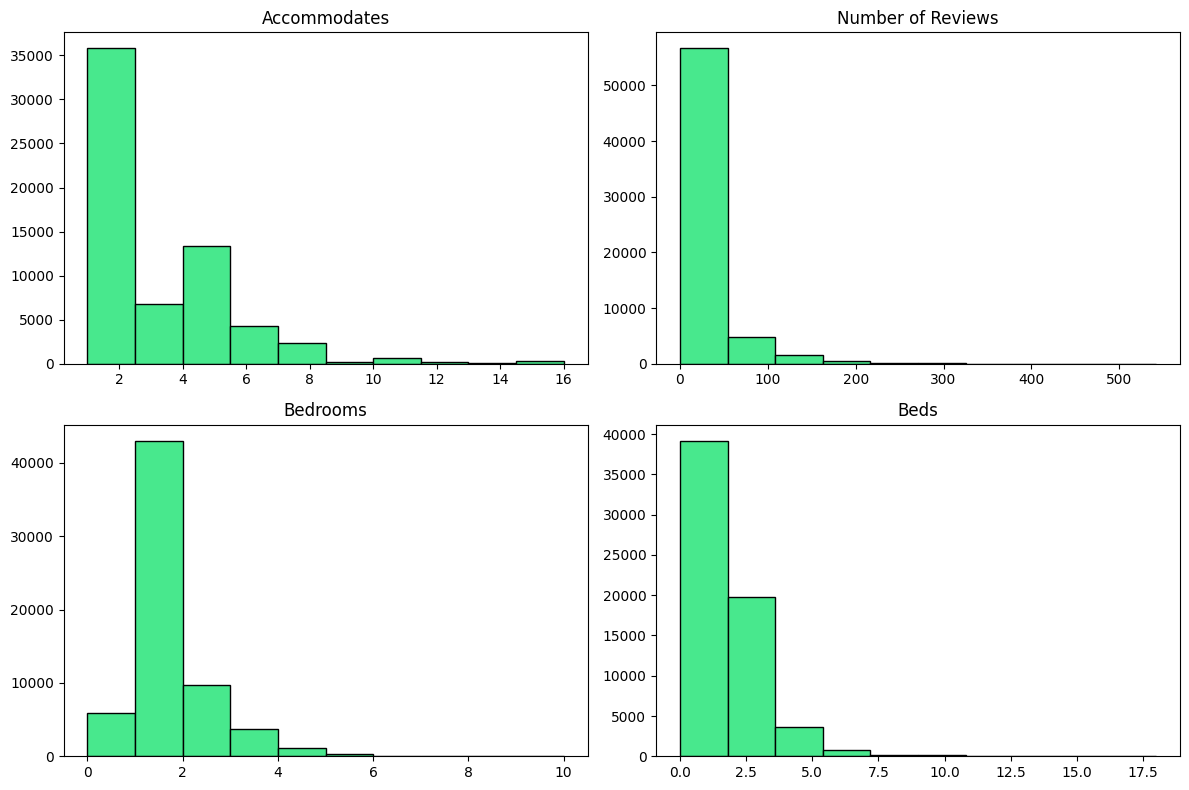

In [88]:
# numeric variable visualization
figure, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].hist(df["accommodates"], **chartStyle)
axes[0,0].set_title("Accommodates")

axes[0,1].hist(df["number_of_reviews"], **chartStyle)
axes[0,1].set_title("Number of Reviews")

axes[1,0].hist(df["bedrooms"], **chartStyle)
axes[1,0].set_title("Bedrooms")

axes[1,1].hist(df["beds"], **chartStyle)
axes[1,1].set_title("Beds")

plt.tight_layout()
plt.show()

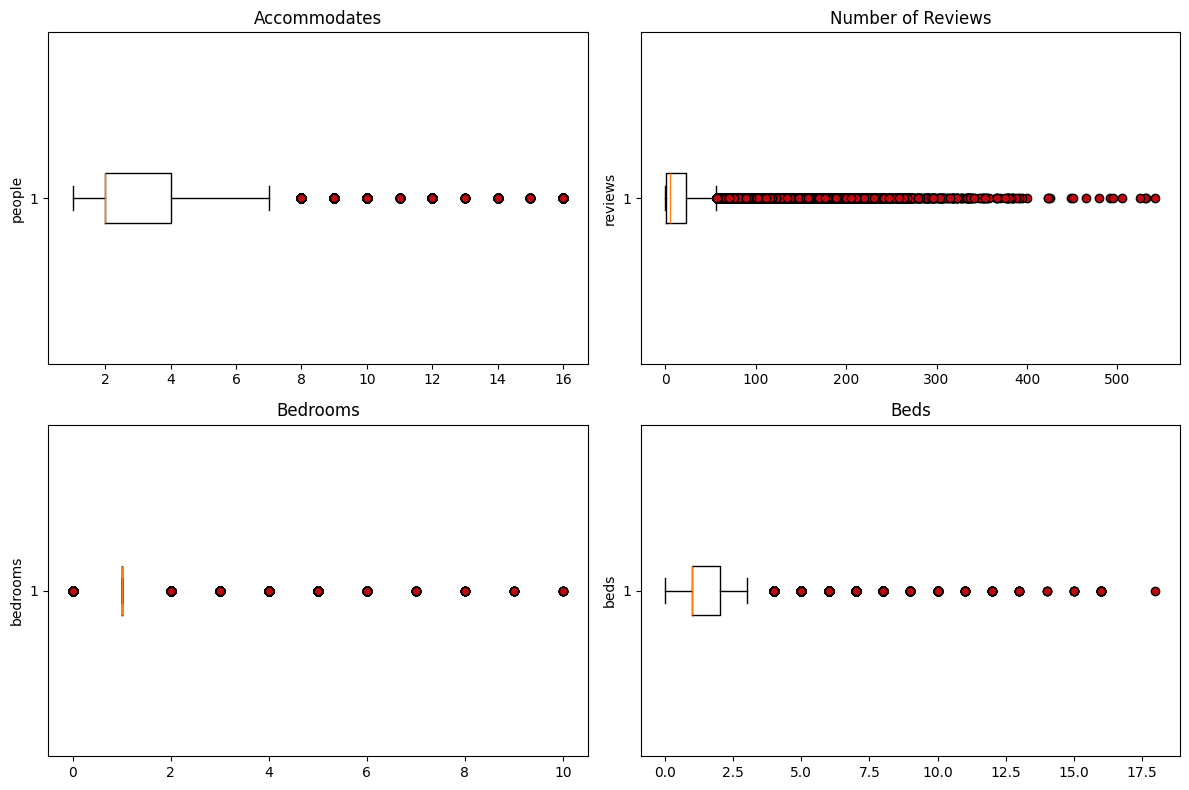

In [89]:
# boxplots to detect outliers
figure, axes = plt.subplots(2,2, figsize=(12,8))
outlierMarkers = dict(markerfacecolor='#c20811', marker='o')
axes[0,0].boxplot(df["accommodates"], flierprops=outlierMarkers, vert=False)
axes[0,0].set_ylabel("people")
axes[0,0].set_title("Accommodates")

axes[0,1].boxplot(df["number_of_reviews"], flierprops=outlierMarkers, vert=False)
axes[0,1].set_ylabel("reviews")
axes[0,1].set_title("Number of Reviews")

axes[1,0].boxplot(df["bedrooms"].dropna(), flierprops=outlierMarkers, vert=False)
axes[1,0].set_ylabel("bedrooms")
axes[1,0].set_title("Bedrooms")

axes[1,1].boxplot(df["beds"].dropna(), flierprops=outlierMarkers, vert=False)
axes[1,1].set_ylabel("beds")
axes[1,1].set_title("Beds")

plt.tight_layout()
plt.show()

# Numerical Column Observations
| variable          | observations                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| ----------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| accommodates      | most listings are around 3 people but the most common ones are for 2 people. There are a few outliers that could be worth looking at correlation with log_price.                                                                                                                                                                                                                                                                                                                                                     |
| number_of_reviews | most listings do not have any reviews so it could be insightful to compare listings with reviews or with more reviews in comparison with listings without any reviews to see if the feedback written by clients correlates with the price or is a good indicator of whether the listing is good and therefore makes the listing more in demand which could increase the price. Huge amount of outliers which would be most listings with many reviews since the big bulk of the listings have little if any reviews. |
| bedrooms          | most listings have one bedroom with a considerable amount being 0 which could be worth looking into although they are probably just one room apartments where everything is in a single room and it wouldn't technically count as having a bedroom. Because the IQR is made up of listings with a single bedroom, any listing with any other value is treated as an outlier.                                                                                                                                         |
| beds              | Most listings have between 0 and 2 or 3 beds and its worth noting that there exist strange listings without any beds which is possible to be linked with the listings with no bedrooms.                                                                                                                                                                                                                                                                                                                              |

In [90]:
# univariate float variable analysis
print("Central Tendency for float columns:\n-----------------------------------")
for col in float_columns:
    print(f"{col}:\nMean: {df[col].mean()}\nMedian: {df[col].median()}\nMode: {df[col].mode(dropna=True).to_list()}\n")

print("Dispersion for float columns:\n----------------------------------")
for col in float_columns:
    print(f"{col}:\nVariance: {df[col].var()}\nStandard Deviation: {df[col].std()}\nRange: {df[col].max() - df[col].min()}\nInterquartile Range: {df[col].quantile(0.75) - df[col].quantile(0.25)}\n")
print("Shape for float columns:\n-----------------------------------")
for col in float_columns:
    print(f"{col}:\nSkewness: {df[col].skew()}\nKurtosis: {df[col].kurt()}\n")

Central Tendency for float columns:
-----------------------------------
log_price:
Mean: 4.780889825169922
Median: 4.700480365792417
Mode: [4.605170185988092]

bathrooms:
Mean: 1.2346530772246178
Median: 1.0
Mode: [1.0]

review_scores_rating:
Mean: 94.04094232331438
Median: 96.0
Mode: [100.0]

host_response_rate:
Mean: 0.9425245874312386
Median: 1.0
Mode: [1.0]

Dispersion for float columns:
----------------------------------
log_price:
Variance: 0.5159109723799653
Standard Deviation: 0.7182694288217795
Range: 7.6004023345004
Interquartile Range: 0.9028677115420143

bathrooms:
Variance: 0.33822430299704576
Standard Deviation: 0.5815705485984015
Range: 8.0
Interquartile Range: 0.0

review_scores_rating:
Variance: 62.01493653965755
Standard Deviation: 7.874956288110909
Range: 80.0
Interquartile Range: 8.0

host_response_rate:
Variance: 0.027305309766140134
Standard Deviation: 0.16524318372066102
Range: 1.0
Interquartile Range: 0.0

Shape for float columns:
-------------------------------

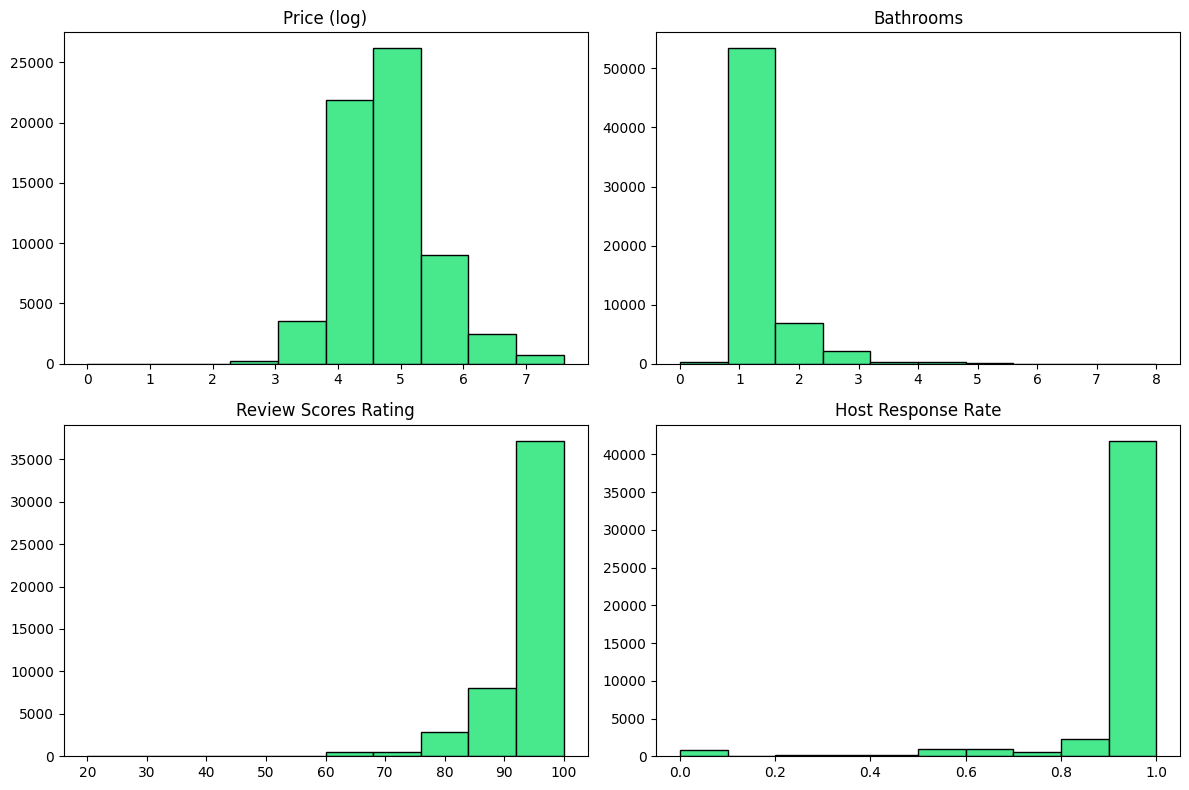

In [91]:
# float variable visualization
figure, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].hist(df["log_price"], **chartStyle)
axes[0,0].set_title("Price (log)")

axes[0,1].hist(df["bathrooms"], **chartStyle)
axes[0,1].set_title("Bathrooms")

axes[1,0].hist(df["review_scores_rating"], **chartStyle)
axes[1,0].set_title("Review Scores Rating")

axes[1,1].hist(df["host_response_rate"], **chartStyle)
axes[1,1].set_title("Host Response Rate")

plt.tight_layout()
plt.show()

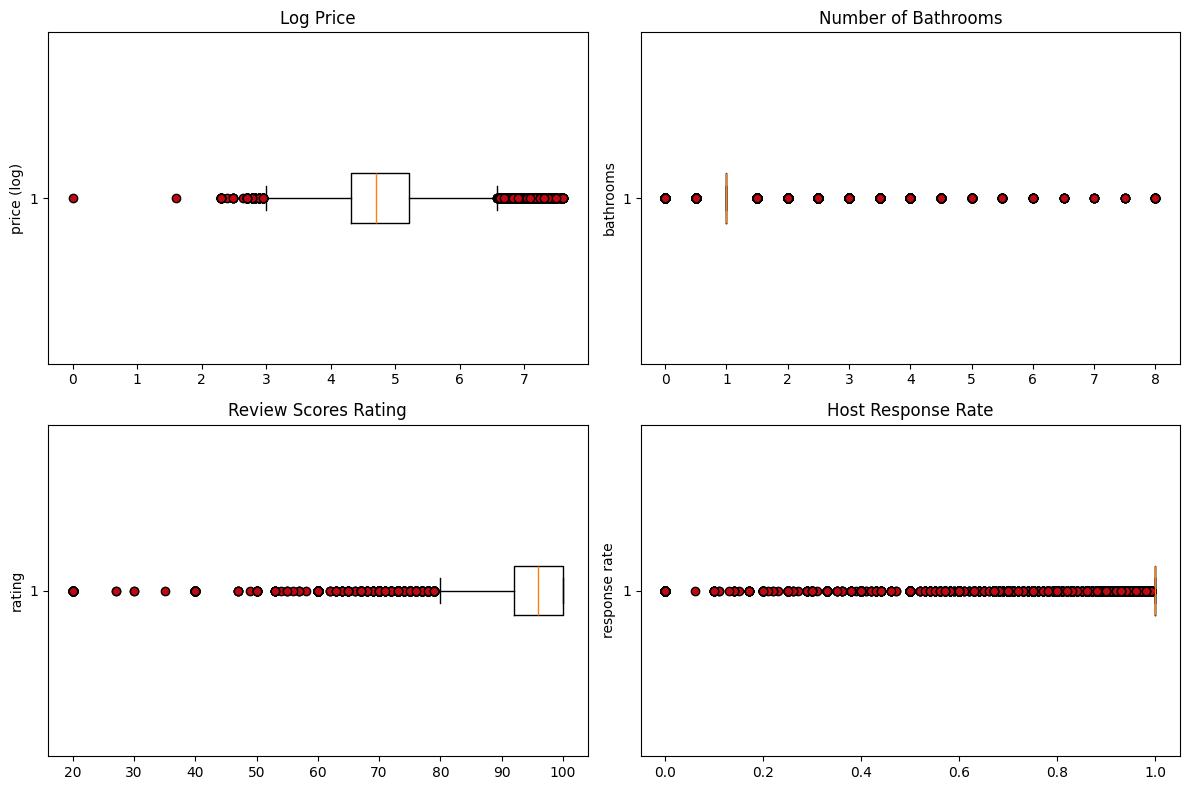

In [92]:
# boxplots to detect outliers
figure, axes = plt.subplots(2,2, figsize=(12,8))
outlierMarkers = dict(markerfacecolor='#c20811', marker='o')
axes[0,0].boxplot(df["log_price"].dropna(), flierprops=outlierMarkers, vert=False)
axes[0,0].set_ylabel("price (log)")
axes[0,0].set_title("Log Price")

axes[0,1].boxplot(df["bathrooms"].dropna(), flierprops=outlierMarkers, vert=False)
axes[0,1].set_ylabel("bathrooms")
axes[0,1].set_title("Number of Bathrooms")

axes[1,0].boxplot(df["review_scores_rating"].dropna(), flierprops=outlierMarkers, vert=False)
axes[1,0].set_ylabel("rating")
axes[1,0].set_title("Review Scores Rating")

axes[1,1].boxplot(df["host_response_rate"].dropna(), flierprops=outlierMarkers, vert=False)
axes[1,1].set_ylabel("response rate")
axes[1,1].set_title("Host Response Rate")

plt.tight_layout()
plt.show()

# Float Column Observations
| variable             | observations                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| ***log_price***      | this is my **target variable**, and up until now is the variable with the least skewed values. Which supports the initial strategic decision to train the model on log prices instead of converting to dollar prices. Listing prices range around 3 to 7 with some outliers worth noting, especially the ones with prices near 0.                                                                                                                                                                                                                   |
| bathrooms            | most listings have a single bathroom, worth looking into correlation with bedrooms since a substantial amount of listings also have a single bedroom. Can observe same outlier detection characteristic with bedroom variable where IQR is 0 and all other values are flagged as outliers.                                                                                                                                                                                                                                                         |
| review_scores_rating | this variable has a substantial number of missing values that will be analyzed separately later on. out of listings that actually have review scores, the scores are heavily skewed to where most listings have a very high rating. My theory is a lot of people with average or bad experiences do not leave a rating; while people with really good or bad experiences will leave ratings. However this does not explain why most ratings are positive and the negative ones are outliers. Needs further analysis and comparing with other data. |
| host_response_rate   | this is a unique variable in the sense that its the percent of times the host responded to messages about the listing. the same IQR being 0 outlier detection pattern is observed here, with most hosts responding to all messages while all other listings are seen as outliers. This variable also has a significant number of missing values which could be interpreted as forgotten listings where the host is inactive and never responded to anything.                                                                                       |

In [93]:
# univariate categorical variable analysis
for col in categorical_columns:
    print(f"{col} Value Counts ({len(df[col].value_counts(dropna=False))} categories):\n-------------------------------------------\n{df[col].value_counts(dropna=False)}\n")

property_type Value Counts (35 categories):
-------------------------------------------
property_type
Apartment             42447
House                 14148
Condominium            2271
Townhouse              1453
Loft                   1060
Other                   520
Guesthouse              432
Bed & Breakfast         387
Bungalow                315
Villa                   150
Dorm                    121
Guest suite              98
Camper/RV                80
Cabin                    67
Hostel                   63
Boutique hotel           62
In-law                   59
Boat                     57
Timeshare                56
Serviced apartment       20
Tent                     13
Castle                   11
Vacation home            11
Hut                       8
Yurt                      8
Treehouse                 6
Chalet                    5
Earth House               3
Tipi                      3
Cave                      2
Train                     2
Casa particular           1
Is

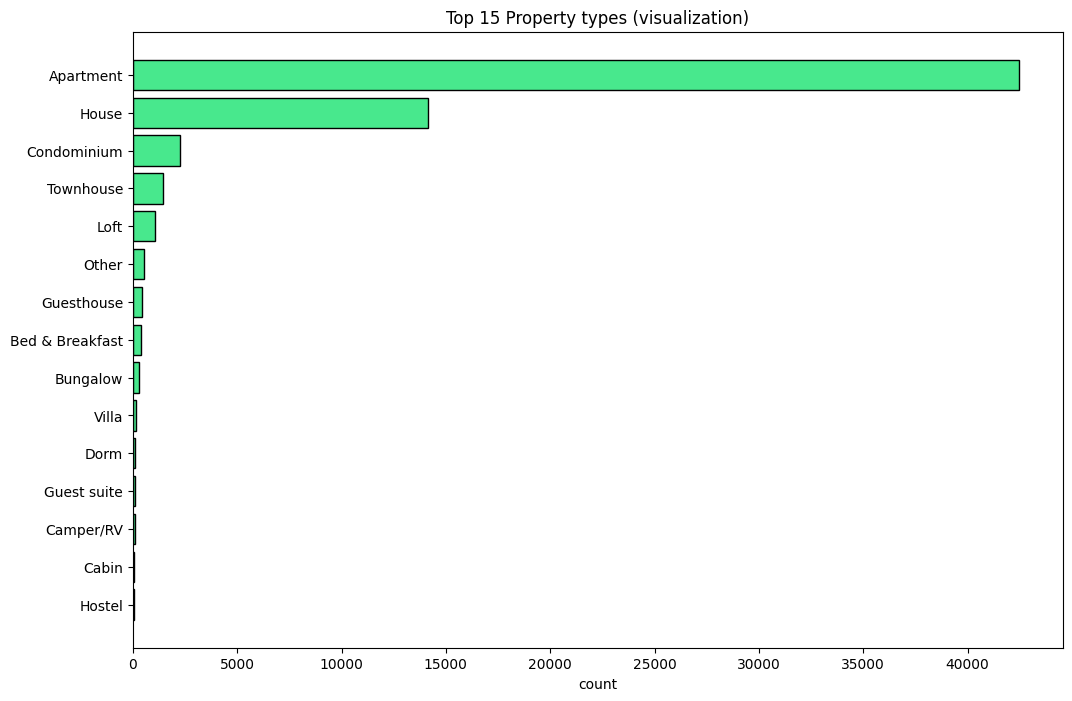

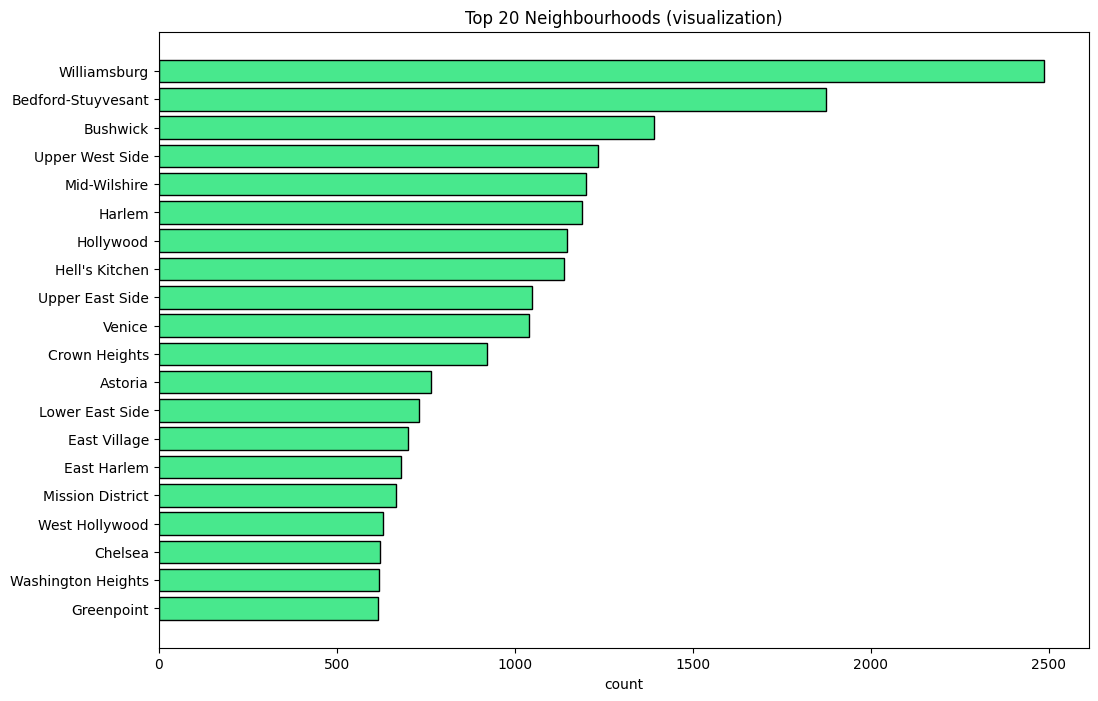

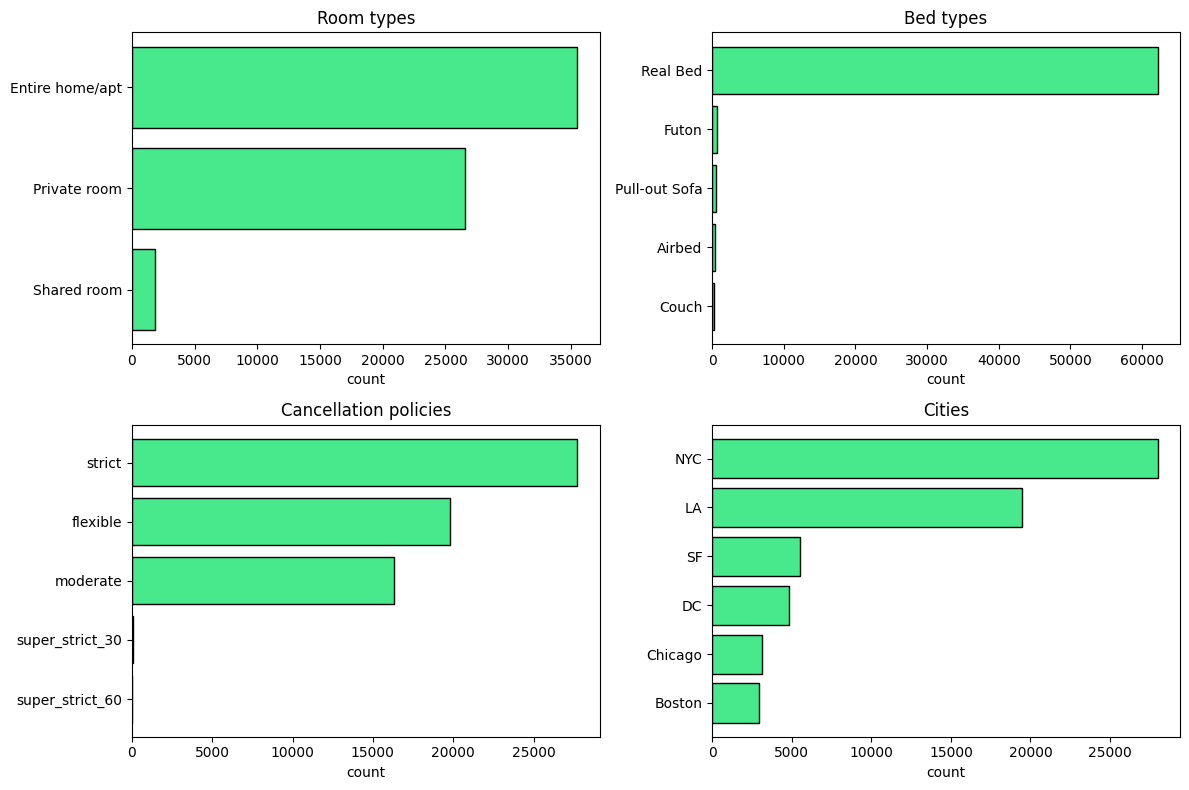

In [94]:
# categorical column visualization
figure, ax = plt.subplots(figsize=(12,8))
plt.barh(df['property_type'].value_counts().head(15).index, df['property_type'].value_counts().head(15), **chartStyle)
plt.title("Top 15 Property types (visualization)")
plt.xlabel("count")

plt.gca().invert_yaxis()
plt.show()

figure, ax = plt.subplots(figsize=(12,8))
plt.barh(df['neighbourhood'].value_counts().head(20).index, df['neighbourhood'].value_counts().head(20), **chartStyle)
plt.title("Top 20 Neighbourhoods (visualization)")
plt.xlabel("count")

plt.gca().invert_yaxis()
plt.show()

figure, axes = plt.subplots(2,2, figsize=(12,8))
axes[0,0].barh(df['room_type'].value_counts().index, df['room_type'].value_counts(), **chartStyle)
axes[0,0].set_title("Room types")
axes[0,0].set_xlabel("count")
axes[0,0].invert_yaxis()

axes[0,1].barh(df['bed_type'].value_counts().index, df['bed_type'].value_counts(), **chartStyle)
axes[0,1].set_title("Bed types")
axes[0,1].set_xlabel("count")
axes[0,1].invert_yaxis()

axes[1,0].barh(df['cancellation_policy'].value_counts().index, df['cancellation_policy'].value_counts(), **chartStyle)
axes[1,0].set_title("Cancellation policies")
axes[1,0].set_xlabel("count")
axes[1,0].invert_yaxis()

axes[1,1].barh(df['city'].value_counts().index, df['city'].value_counts(), **chartStyle)
axes[1,1].set_title("Cities")
axes[1,1].set_xlabel("count")
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

# Categorical Columns Observations

| variable            | observations                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| property_type       | most listings fall under apartments or houses. It makes sense a lot of listings are apartments which are probably also the listings that have a single bedroom and bed, which were the most common number for those two variables. May be worth to categorize many of the categories with few listings along with the 'other' category in order to analyze them together as rare listings and see how they affect price in general. My assumption would be that unique listings drive price up since they could be considered more exclusive or special. Then again another explanation could be that there is much lesser demand for these and that would also make prices go up for the people who actually are interested in them. |
| room_type           | the most popular room types are entire home/apartments. Its interesting to have them as a single category and there are about 10000 more listings for this category than for private rooms and about 32000 more listings than shared room.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| bed_type            | most listings have real beds which is not surprising at all. Bed types may not be a good indicator for pricing since with these few values for other types there could be a lack of evidence to conclusively have any effect on pricing but still needs to be tested.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| cancellation_policy | a lot of listings have strict cancellation policies but a good number of them have flexible or moderate policies. Could be worth adding the super strict categories onto the strict one since there are so few super strict values and not enough to actually determine if they have any influence on price. Further insight needed to decide.                                                                                                                                                                                                                                                                                                                                                                                        |
| city                | the two cities with the most listings are NYC and LA but all cities have enough values to be considered and draw conclusions from.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| neighbourhood       | there are too many values to visualize on a single chart and there are a considerable number of listings on many columns. It could be worth to feature engineer the neighbourhoods into areas or to simply just use the data from the city column. Another alternative could be to set a threshold if a neighbourhood has few listings and pile them all unto an 'other' category, however I do not think this is the right method to handle the categories. Will most likely end up having to be feature engineered.                                                                                                                                                                                                                 |

In [95]:
# univariate boolean variable analysis
for col in boolean_columns:
    print(f"{col} Value Counts:\n-------------------------------------------\n{df[col].value_counts(dropna=False)}\n")

cleaning_fee Value Counts:
-------------------------------------------
cleaning_fee
True     46766
False    17176
Name: count, dtype: Int64

host_has_profile_pic Value Counts:
-------------------------------------------
host_has_profile_pic
True     63580
False      203
<NA>       159
Name: count, dtype: Int64

host_identity_verified Value Counts:
-------------------------------------------
host_identity_verified
True     42717
False    21066
<NA>       159
Name: count, dtype: Int64

instant_bookable Value Counts:
-------------------------------------------
instant_bookable
False    47051
True     16891
Name: count, dtype: Int64



# Boolean Column Observations
| variable               | observations                                                                                                                                                                                                                                                                                                                                                                      |
| ---------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| cleaning_fee           | Approximately 26% of listings do not have a cleaning fee so the norm or the most common thing is for listings to have a cleaning fee, which could mean the host included this in the listing price and therefore listings without a cleaning fee would be more expensive. The other case could be that maybe these listings have no cleaning service and would be lower on price. |
| host_has_profile_pic   | An overwhelming amount of hosts have a profile picture.                                                                                                                                                                                                                                                                                                                           |
| host_identity_verified | Approximately 33% of listings are not verified. This variable and the profile picture variable have exactly 159 missing values, these could be profiles that did not finish a setup phase and will be evaluated on the missing data analysis.                                                                                                                                     |
| instant_bookable       | Approximately 25% of listings are instantly bookable.                                                                                                                                                                                                                                                                                                                             |